# Lab 5 Water Quality Analysis

This notebook implements the airborne workflow, Sentinel-2 acquisition, and the
cross-sensor comparison phase of the Lab 5 pipeline. It loads one ENVI scene,
derives airborne water-quality products, prepares the closest Sentinel-2 scene
for the same footprint, and compares both sources on a shared grid.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.lab5.envi_utils import (
    build_invalid_band_mask,
    find_nearest_band,
    get_ignore_value,
    get_rgb_bands,
    load_envi_image,
    parse_wavelengths,
    read_rgb,
)
from src.lab5.indices import (
    band_by_wavelength,
    chlorophyll_red_edge_peak,
    composite_by_wavelengths,
    doc_proxy_green_red,
    ndci,
    ndti,
    stretch_composite,
)
from src.lab5.sentinel2 import (
    SENTINEL2_REQUIRED_BANDS,
    align_array_to_grid,
    build_overlap_mask,
    comparison_output_dir,
    describe_item,
    download_band,
    find_cached_band_files,
    load_local_stack,
    open_catalog,
    scene_bbox_wgs84_from_envi,
    scene_grid_from_envi,
    search_s2_items,
    select_best_item,
    summarize_pair,
)

SCENE_PATH = REPO_ROOT / "data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr"
SENTINEL2_DIR = REPO_ROOT / "data/sentinel2"
OUTPUTS_ROOT = REPO_ROOT / "data/outputs"
TARGET_DATE = "2025-06-17"
S2_DAY_WINDOW = 5
S2_CLOUD_LIMIT = 20.0

SCENE_PATH


PosixPath('/Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr')

## Scene Summary

The first step is to open the hyperspectral scene, read the wavelength metadata,
mark invalid bands, and resolve the nearest usable airborne bands for the Lab 5
products.


In [2]:
img = load_envi_image(SCENE_PATH)
meta = img.metadata
wavelengths = parse_wavelengths(meta)
ignore_value = get_ignore_value(meta)
invalid_mask = build_invalid_band_mask(meta)
rgb_default = read_rgb(img, get_rgb_bands(meta), ignore_value)

def resolve_target(target_nm: float) -> tuple[int, float]:
    band_index = find_nearest_band(wavelengths, target_nm, invalid_mask)
    return band_index, float(wavelengths[band_index])

target_lookup = {
    target_nm: resolve_target(target_nm)
    for target_nm in (490, 560, 665, 705, 740, 842, 1610)
}

metadata_summary = pd.DataFrame([
    {
        "scene_id": SCENE_PATH.stem,
        "rows": img.nrows,
        "cols": img.ncols,
        "bands": img.nbands,
        "ignore_value": ignore_value,
        "invalid_band_count": int(invalid_mask.sum()) if invalid_mask is not None else 0,
        "wavelength_count": int(len(wavelengths)) if wavelengths is not None else 0,
    }
])

band_summary = pd.DataFrame(
    [
        {
            "target_nm": target_nm,
            "band_index": band_index,
            "actual_wavelength_nm": actual_wavelength,
        }
        for target_nm, (band_index, actual_wavelength) in sorted(target_lookup.items())
    ]
)

display(metadata_summary)
display(band_summary)


,scene_id,rows,cols,bands,ignore_value,invalid_band_count,wavelength_count
0,221000_Odra_HS_Blok_A_008_VS_join_atm,4300,2001,456,15000.0,155,456


,target_nm,band_index,actual_wavelength_nm
0,490,24,490.85
1,560,46,561.17
2,665,78,663.46
3,705,85,685.84
4,740,102,740.18
5,842,134,842.47
6,1610,292,1612.08


## Natural And False-Color Composites

The natural RGB comes from the ENVI `default bands` metadata. The false-color
composites below follow the Lab 5 execution plan:

- vegetation composite: `842 / 665 / 560`
- moisture composite: `1610 / 842 / 665`
- water-focused composite: `705 / 560 / 490`


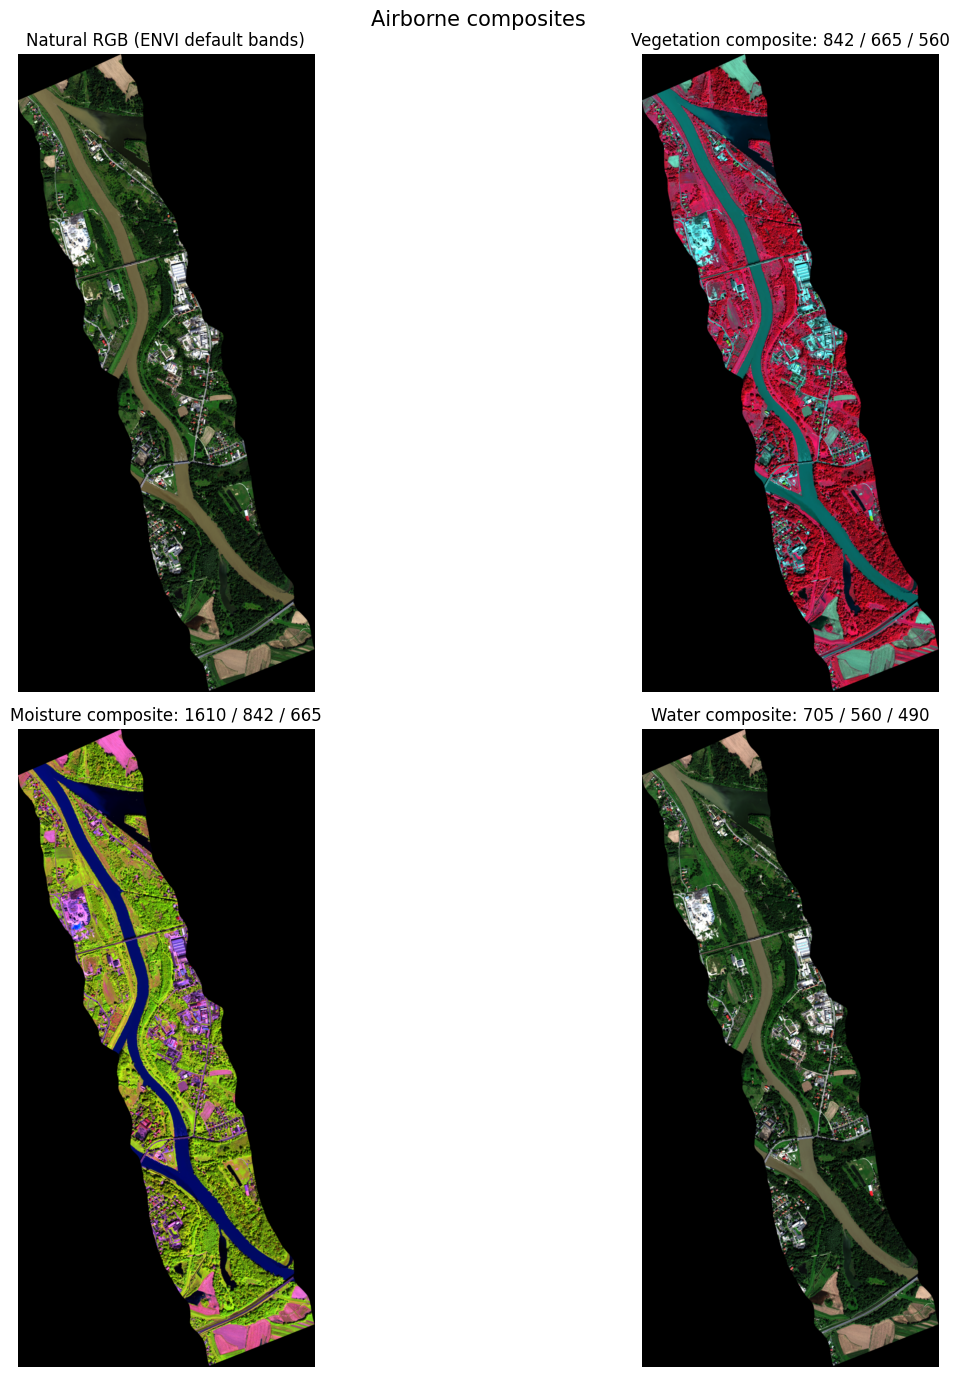

In [3]:
vegetation_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (842, 665, 560),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
moisture_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (1610, 842, 665),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
water_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (705, 560, 490),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne composites", fontsize=15)

axes[0, 0].imshow(rgb_default, interpolation="bilinear")
axes[0, 0].set_title("Natural RGB (ENVI default bands)")
axes[0, 0].axis("off")

axes[0, 1].imshow(vegetation_rgb, interpolation="bilinear")
axes[0, 1].set_title("Vegetation composite: 842 / 665 / 560")
axes[0, 1].axis("off")

axes[1, 0].imshow(moisture_rgb, interpolation="bilinear")
axes[1, 0].set_title("Moisture composite: 1610 / 842 / 665")
axes[1, 0].axis("off")

axes[1, 1].imshow(water_rgb, interpolation="bilinear")
axes[1, 1].set_title("Water composite: 705 / 560 / 490")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Airborne Water-Quality Index Maps

This section computes the airborne-only Lab 5 products implemented in
`src/lab5/indices.py`.


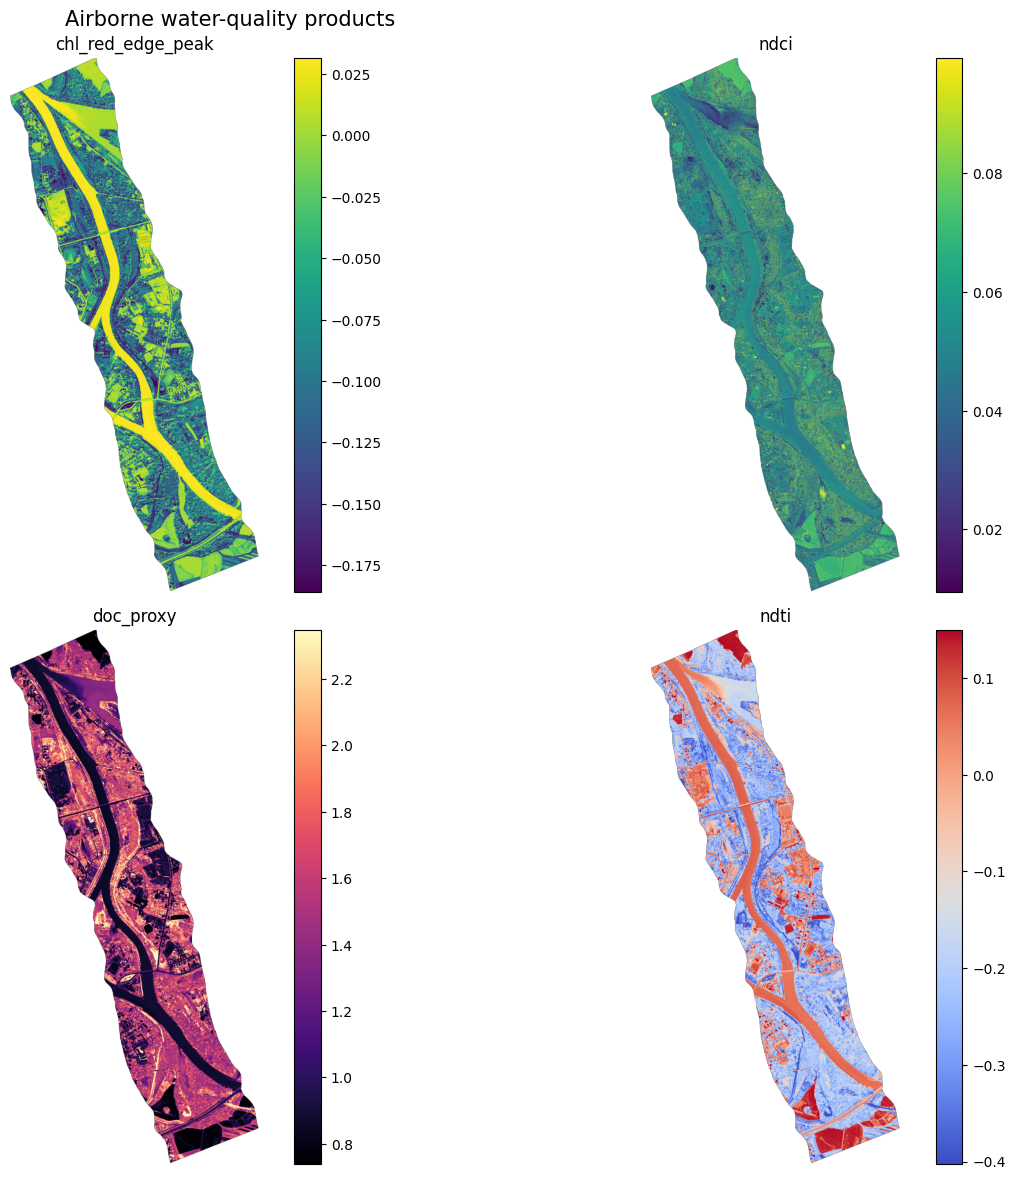

,index,valid_pixels,mean,std,p05,median,p95
0,chl_red_edge_peak,3174220,-0.063779,0.066540,-0.168553,-0.064473,0.029273
1,ndci,3174220,0.053557,0.024207,0.019653,0.053528,0.087221
2,doc_proxy,3174220,1.386396,0.446843,0.780269,1.414966,2.140762
3,ndti,3174220,-0.131950,0.163333,-0.363212,-0.171831,0.123426


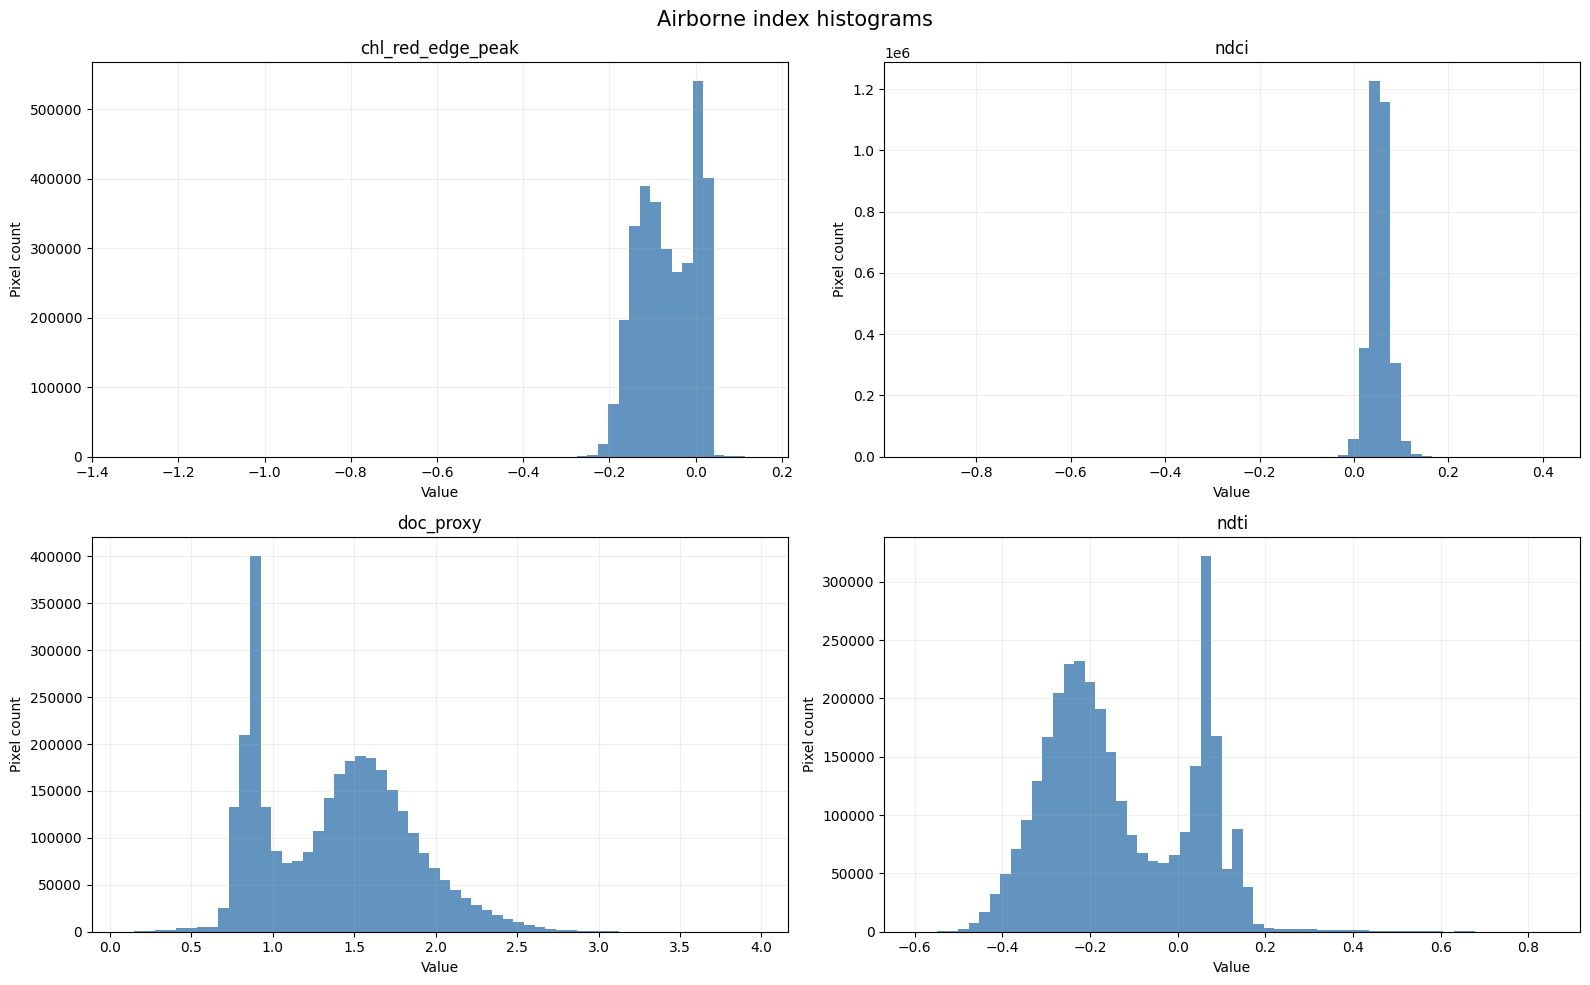

In [4]:
r560 = band_by_wavelength(img, wavelengths, 560, invalid_mask=invalid_mask, ignore_value=ignore_value)
r665 = band_by_wavelength(img, wavelengths, 665, invalid_mask=invalid_mask, ignore_value=ignore_value)
r705 = band_by_wavelength(img, wavelengths, 705, invalid_mask=invalid_mask, ignore_value=ignore_value)
r740 = band_by_wavelength(img, wavelengths, 740, invalid_mask=invalid_mask, ignore_value=ignore_value)

index_maps = {
    "chl_red_edge_peak": chlorophyll_red_edge_peak(r665, r705, r740),
    "ndci": ndci(r665, r705),
    "doc_proxy": doc_proxy_green_red(r560, r665),
    "ndti": ndti(r560, r665),
}

display_cmaps = {
    "chl_red_edge_peak": "viridis",
    "ndci": "viridis",
    "doc_proxy": "magma",
    "ndti": "coolwarm",
}

def finite_limits(array: np.ndarray) -> tuple[float, float]:
    values = np.asarray(array)[np.isfinite(array)]
    if values.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(values, [2, 98])
    if lo == hi:
        return float(lo - 1e-6), float(hi + 1e-6)
    return float(lo), float(hi)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne water-quality products", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    lo, hi = finite_limits(array)
    image = ax.imshow(array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

airborne_index_stats = pd.DataFrame(
    [
        {
            "index": name,
            "valid_pixels": int(values.size),
            "mean": float(np.mean(values)) if values.size else np.nan,
            "std": float(np.std(values)) if values.size else np.nan,
            "p05": float(np.percentile(values, 5)) if values.size else np.nan,
            "median": float(np.percentile(values, 50)) if values.size else np.nan,
            "p95": float(np.percentile(values, 95)) if values.size else np.nan,
        }
        for name, array in index_maps.items()
        for values in [array[np.isfinite(array)]]
    ]
)
display(airborne_index_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Airborne index histograms", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    values = array[np.isfinite(array)]
    ax.hist(values, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Pixel count")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Sentinel-2 Search And Local Cache

This section converts the airborne footprint to WGS84, searches the Planetary
Computer STAC catalog near `2025-06-17`, and also checks whether a complete local
band cache already exists.


In [5]:
target_grid = scene_grid_from_envi(meta)
scene_bbox_wgs84 = scene_bbox_wgs84_from_envi(meta)
selected_item_summary = None

try:
    catalog = open_catalog()
    s2_items = search_s2_items(
        scene_bbox_wgs84,
        TARGET_DATE,
        day_window=S2_DAY_WINDOW,
        cloud_limit=S2_CLOUD_LIMIT,
        catalog=catalog,
    )
    s2_candidates = pd.DataFrame([describe_item(item, TARGET_DATE) for item in s2_items])
    s2_item = select_best_item(s2_items, TARGET_DATE)
    selected_item_summary = describe_item(s2_item, TARGET_DATE)
except Exception as exc:
    s2_items = []
    s2_candidates = pd.DataFrame()
    s2_item = None
    print(f"Live Sentinel-2 search unavailable in this environment: {exc}")

cached_band_files = find_cached_band_files(
    SENTINEL2_DIR,
    item_id=s2_item.id if s2_item is not None else None,
)
if not cached_band_files and s2_item is None:
    cached_band_files = find_cached_band_files(SENTINEL2_DIR)

if not s2_candidates.empty:
    display(s2_candidates)
if selected_item_summary is not None:
    display(pd.DataFrame([selected_item_summary]))

if cached_band_files:
    cached_table = pd.DataFrame(
        [
            {"band": band_name, "cached_path": str(path)}
            for band_name, path in cached_band_files.items()
        ]
    )
    display(cached_table)
else:
    print("No complete local Sentinel-2 cache found yet.")


,id,datetime,days_from_target,eo_cloud_cover,platform,mgrs_tile
0,S2C_MSIL2A_20250615T095051_R079_T33UYR_2025061...,2025-06-15T09:50:51.025000+00:00,2,0.461973,Sentinel-2C,33UYR
1,S2B_MSIL2A_20250613T100029_R122_T33UYR_2025061...,2025-06-13T10:00:29.025000+00:00,4,1.484568,Sentinel-2B,33UYR


,id,datetime,days_from_target,eo_cloud_cover,platform,mgrs_tile
0,S2C_MSIL2A_20250615T095051_R079_T33UYR_2025061...,2025-06-15T09:50:51.025000+00:00,2,0.461973,Sentinel-2C,33UYR


,band,cached_path
0,B03,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,B04,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,B05,/Users/ernest.molczan/PycharmProjects/eolabs-c...
3,B06,/Users/ernest.molczan/PycharmProjects/eolabs-c...
4,B08,/Users/ernest.molczan/PycharmProjects/eolabs-c...
5,B11,/Users/ernest.molczan/PycharmProjects/eolabs-c...


## Sentinel-2 Band Download And Local Load

If a live STAC item is available, this cell downloads and reprojects the required
Sentinel-2 bands to the airborne grid. If not, it falls back to the most relevant
complete local cache.


In [6]:
if s2_item is not None:
    SENTINEL2_DIR.mkdir(parents=True, exist_ok=True)
    s2_band_files = {
        band_name: download_band(s2_item, band_name, SENTINEL2_DIR, target_grid)
        for band_name in SENTINEL2_REQUIRED_BANDS
    }
else:
    s2_band_files = cached_band_files

if not s2_band_files:
    print("Skipping Sentinel-2 stack load because no live item or cached band set is available.")
    s2_stack = {}
else:
    s2_stack = load_local_stack(s2_band_files)
    download_table = pd.DataFrame(
        [
            {
                "band": band_name,
                "path": str(path),
                "shape": tuple(s2_stack[band_name].shape),
            }
            for band_name, path in s2_band_files.items()
        ]
    )
    display(download_table)


,band,path,shape
0,B03,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
1,B04,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
2,B05,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
3,B06,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
4,B08,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
5,B11,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"


## Cross-Sensor Alignment And Overlap

The comparison grid is the shared airborne scene grid already used for the
Sentinel-2 cache. Airborne products are aligned to that grid, Sentinel-2 products
are computed on the same grid, and the overlap mask keeps only pixels that are
valid in both sources.


,source,product,shape
0,airborne,chl_red_edge_peak,"(4300, 2001)"
1,airborne,ndci,"(4300, 2001)"
2,airborne,doc_proxy,"(4300, 2001)"
3,airborne,ndti,"(4300, 2001)"
4,sentinel2,chl_red_edge_peak,"(4300, 2001)"
5,sentinel2,ndci,"(4300, 2001)"
6,sentinel2,doc_proxy,"(4300, 2001)"
7,sentinel2,ndti,"(4300, 2001)"


,valid_overlap_pixels,total_pixels,coverage_fraction
0,3174220,8604300,0.368911


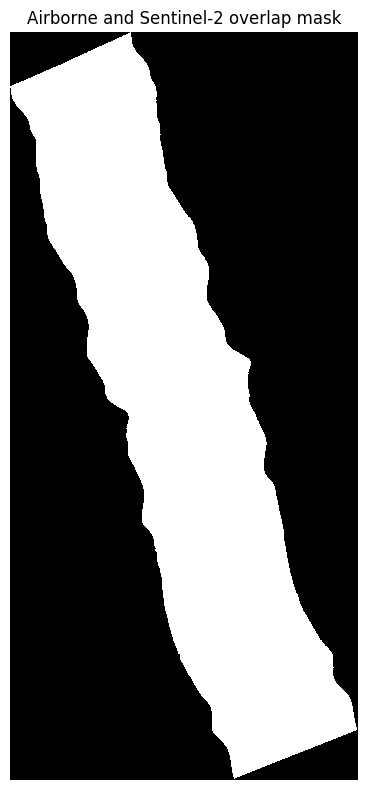

In [7]:
comparison_grid = target_grid
airborne_products = {
    name: align_array_to_grid(array, target_grid, comparison_grid)
    for name, array in index_maps.items()
}

if not s2_stack:
    sentinel_products = {}
    overlap_mask = np.zeros((comparison_grid.height, comparison_grid.width), dtype=bool)
    print("Skipping comparison setup because Sentinel-2 data is unavailable.")
else:
    s2_reflectance = {
        band_name: np.where(np.asarray(array, dtype=np.float32) > 0.0, np.asarray(array, dtype=np.float32), np.nan)
        for band_name, array in s2_stack.items()
    }
    sentinel_products = {
        "chl_red_edge_peak": chlorophyll_red_edge_peak(
            s2_reflectance["B04"],
            s2_reflectance["B05"],
            s2_reflectance["B06"],
        ),
        "ndci": ndci(s2_reflectance["B04"], s2_reflectance["B05"]),
        "doc_proxy": doc_proxy_green_red(s2_reflectance["B03"], s2_reflectance["B04"]),
        "ndti": ndti(s2_reflectance["B03"], s2_reflectance["B04"]),
    }
    overlap_mask = build_overlap_mask(airborne_products, sentinel_products)

    shape_table = pd.DataFrame(
        [
            {"source": "airborne", "product": name, "shape": tuple(array.shape)}
            for name, array in airborne_products.items()
        ]
        + [
            {"source": "sentinel2", "product": name, "shape": tuple(array.shape)}
            for name, array in sentinel_products.items()
        ]
    )
    overlap_summary = pd.DataFrame(
        [
            {
                "valid_overlap_pixels": int(overlap_mask.sum()),
                "total_pixels": int(overlap_mask.size),
                "coverage_fraction": float(overlap_mask.mean()),
            }
        ]
    )
    display(shape_table)
    display(overlap_summary)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(overlap_mask, cmap="gray", interpolation="nearest")
    ax.set_title("Airborne and Sentinel-2 overlap mask")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## Cross-Sensor Comparison Outputs

This section applies the overlap mask to every comparison plot, computes summary
statistics, and saves the maps, histograms, scatter plots, and CSV table under
`data/outputs/comparison/<scene_id>/`.


,index,valid_pixels,airborne_mean,sentinel_mean,bias_s2_minus_airborne,mae,rmse,pearson_r
0,chl_red_edge_peak,3174220,-0.063779,-0.051085,0.012694,0.045287,0.057459,0.539968
1,ndci,3174220,0.053557,0.159910,0.106352,0.112106,0.130138,0.055569
2,doc_proxy,3174220,1.386396,1.131338,-0.255058,0.397087,0.495118,0.343696
3,ndti,3174220,-0.131950,-0.059891,0.072059,0.145653,0.169189,0.367973


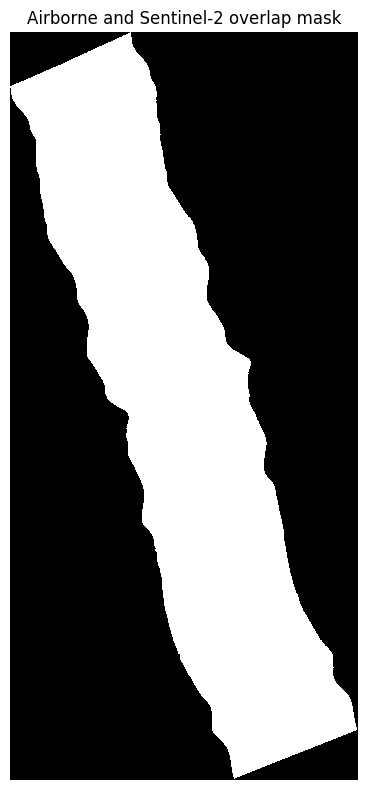

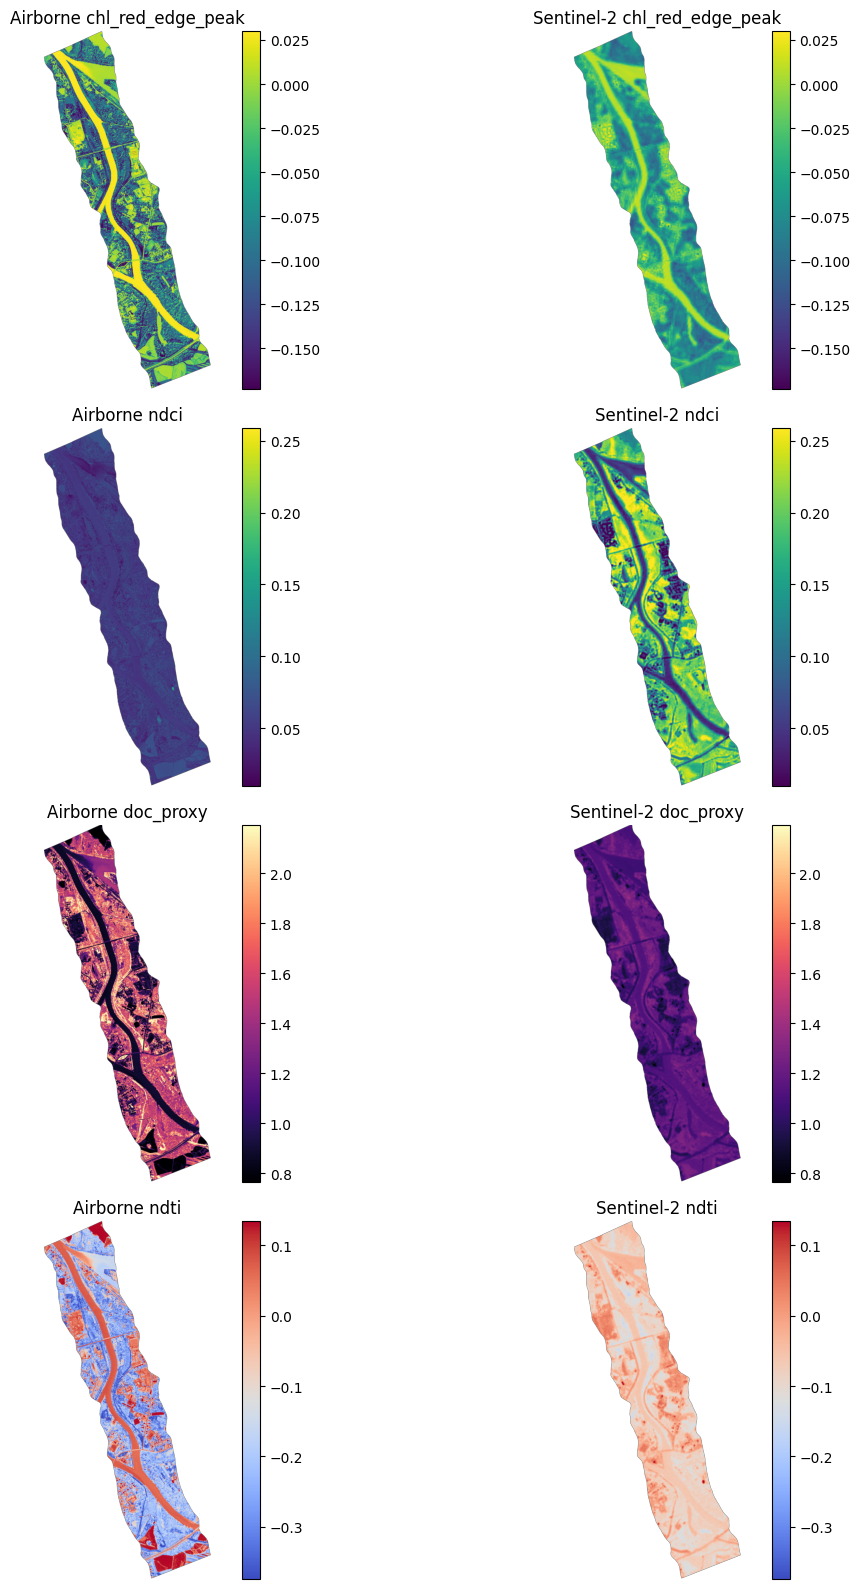

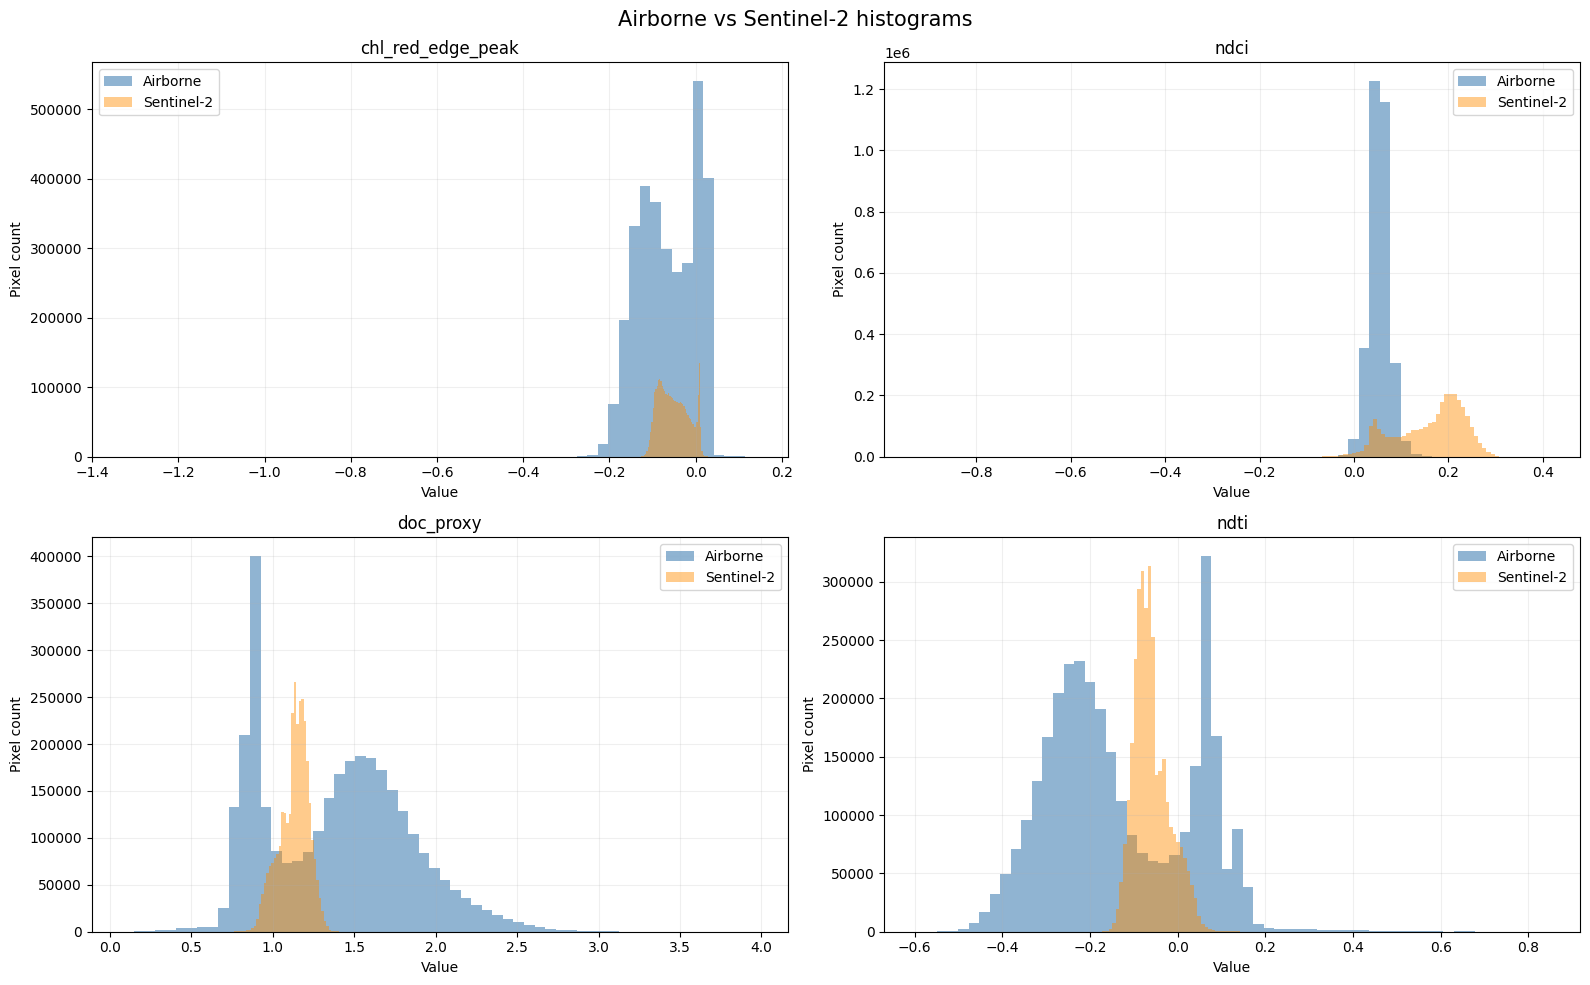

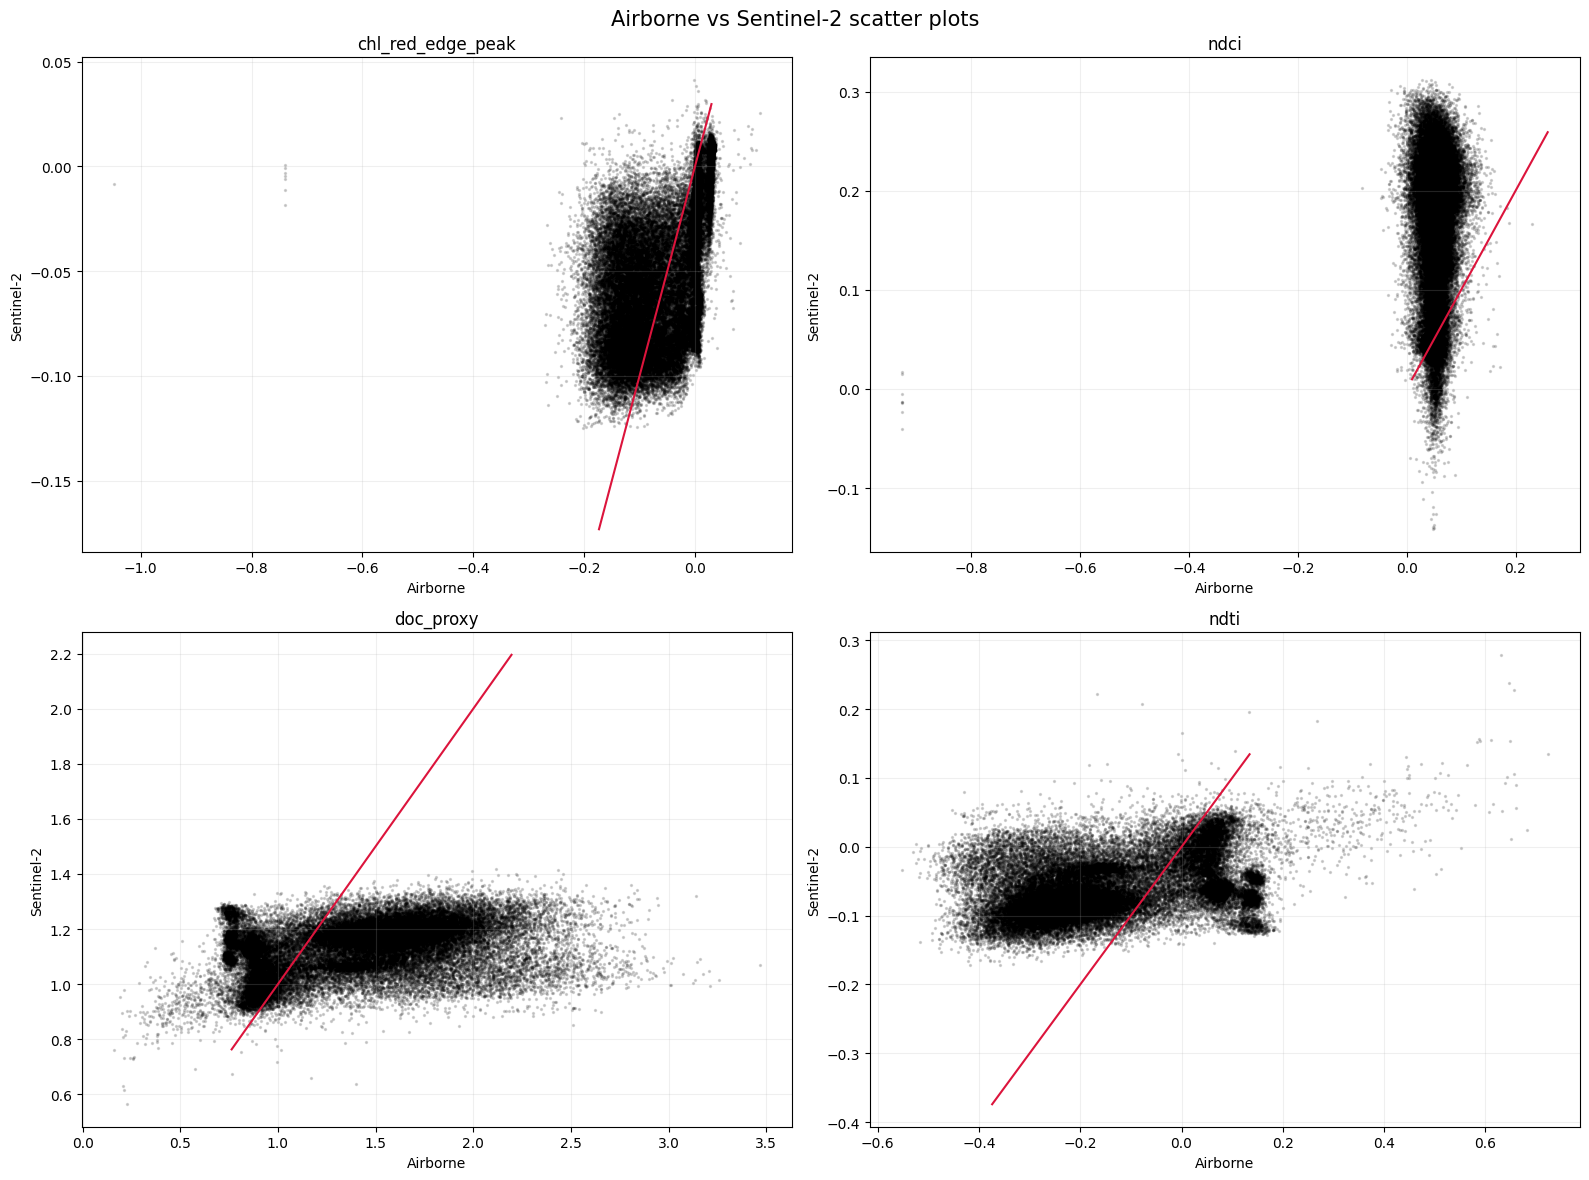

,file,path
0,comparison_histograms.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,comparison_maps.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,comparison_scatter.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
3,comparison_stats.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
4,overlap_mask.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...


Saved comparison outputs to /Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/outputs/comparison/221000_Odra_HS_Blok_A_008_VS_join_atm


In [8]:
def sample_xy(x: np.ndarray, y: np.ndarray, max_points: int = 50000, seed: int = 42) -> tuple[np.ndarray, np.ndarray]:
    if x.size <= max_points:
        return x, y
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(x.size, size=max_points, replace=False)
    return x[sample_idx], y[sample_idx]

if not sentinel_products or int(overlap_mask.sum()) == 0:
    comparison_stats = pd.DataFrame()
    print("Skipping comparison outputs because no shared valid overlap is available.")
else:
    output_dir = comparison_output_dir(OUTPUTS_ROOT, SCENE_PATH.stem)
    masked_airborne = {
        name: np.where(overlap_mask, array, np.nan)
        for name, array in airborne_products.items()
    }
    masked_sentinel = {
        name: np.where(overlap_mask, array, np.nan)
        for name, array in sentinel_products.items()
    }

    comparison_stats = pd.DataFrame(
        [
            {"index": name, **summarize_pair(masked_airborne[name], masked_sentinel[name], overlap_mask)}
            for name in masked_airborne
        ]
    )
    comparison_stats.to_csv(output_dir / "comparison_stats.csv", index=False)
    display(comparison_stats)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(overlap_mask, cmap="gray", interpolation="nearest")
    ax.set_title("Airborne and Sentinel-2 overlap mask")
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(output_dir / "overlap_mask.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(len(masked_airborne), 2, figsize=(14, 4 * len(masked_airborne)), subplot_kw={"aspect": "auto"})
    if len(masked_airborne) == 1:
        axes = np.asarray([axes])
    for row_idx, name in enumerate(masked_airborne):
        airborne_array = masked_airborne[name]
        sentinel_array = masked_sentinel[name]
        combined = np.concatenate([airborne_array[overlap_mask], sentinel_array[overlap_mask]])
        lo, hi = finite_limits(combined)

        left = axes[row_idx, 0]
        right = axes[row_idx, 1]

        image_left = left.imshow(airborne_array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
        left.set_title(f"Airborne {name}")
        left.axis("off")
        plt.colorbar(image_left, ax=left, fraction=0.046, pad=0.04)

        image_right = right.imshow(sentinel_array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
        right.set_title(f"Sentinel-2 {name}")
        right.axis("off")
        plt.colorbar(image_right, ax=right, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(output_dir / "comparison_maps.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Airborne vs Sentinel-2 histograms", fontsize=15)
    for ax, name in zip(axes.flat, masked_airborne, strict=True):
        airborne_values = masked_airborne[name][overlap_mask]
        sentinel_values = masked_sentinel[name][overlap_mask]
        ax.hist(airborne_values, bins=60, alpha=0.6, label="Airborne", color="steelblue")
        ax.hist(sentinel_values, bins=60, alpha=0.45, label="Sentinel-2", color="darkorange")
        ax.set_title(name)
        ax.set_xlabel("Value")
        ax.set_ylabel("Pixel count")
        ax.legend()
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(output_dir / "comparison_histograms.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Airborne vs Sentinel-2 scatter plots", fontsize=15)
    for ax, name in zip(axes.flat, masked_airborne, strict=True):
        airborne_values = masked_airborne[name][overlap_mask]
        sentinel_values = masked_sentinel[name][overlap_mask]
        sample_airborne, sample_sentinel = sample_xy(airborne_values, sentinel_values)
        ax.scatter(sample_airborne, sample_sentinel, s=2, alpha=0.15, color="black")
        combined = np.concatenate([sample_airborne, sample_sentinel])
        lo, hi = finite_limits(combined)
        ax.plot([lo, hi], [lo, hi], color="crimson", linewidth=1.5)
        ax.set_title(name)
        ax.set_xlabel("Airborne")
        ax.set_ylabel("Sentinel-2")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(output_dir / "comparison_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    output_table = pd.DataFrame(
        [{"file": path.name, "path": str(path)} for path in sorted(output_dir.iterdir())]
    )
    display(output_table)
    print(f"Saved comparison outputs to {output_dir}")
